In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")

TICKER   = "SPY"
LOOKBACK = "60d"
INTERVAL = "5m"

Q   = 50_000   # shares to buy
FEE = 0.001    # transaction fee per share

spy = yf.download(
    TICKER,
    period=LOOKBACK,
    interval=INTERVAL,
    progress=False,
    auto_adjust=False
)

if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

spy.columns.name = None

spy = spy.rename(columns={
    "Open": "open", "High": "high",
    "Low": "low",  "Close": "close", "Volume": "volume"
})

spy = spy[["open", "high", "low", "close", "volume"]].dropna().copy()

print("Shape:", spy.shape)
print("Date range:", spy.index.min(), "to", spy.index.max())
spy.head()

Shape: (4451, 5)
Date range: 2025-12-12 14:30:00+00:00 to 2026-03-11 14:10:00+00:00


,open,high,low,close,volume
Datetime,,,,,
2025-12-12 14:30:00+00:00,688.169983,688.684998,687.700012,688.414978,3232551
2025-12-12 14:35:00+00:00,688.409973,688.869995,688.210022,688.771973,799743
2025-12-12 14:40:00+00:00,688.789978,688.880005,687.789978,687.940002,1236915
2025-12-12 14:45:00+00:00,687.940002,688.150024,687.364990,687.389893,1184345
2025-12-12 14:50:00+00:00,687.380005,688.019775,687.169983,687.869995,1033771


In [ ]:
spy = spy.tz_convert("America/New_York")
spy = spy.between_time("09:30", "16:00").copy()

spy["date"]   = spy.index.date
spy["bucket"] = spy.groupby("date").cumcount()

spy["ret"] = spy["close"].pct_change()
first_bar_mask = spy["bucket"] == 0
spy.loc[first_bar_mask, "ret"] = np.nan

# Rolling intraday volatility
VOL_WINDOW = 20
spy["vol"] = spy["ret"].rolling(VOL_WINDOW).std()

# Half-spread proxy: spread = SPREAD_MULT * vol * price
SPREAD_MULT = 0.1
ETA         = 0.1    # temporary-impact coefficient

spy["half_spread"] = SPREAD_MULT * spy["vol"] * spy["close"]
spy["half_spread"] = spy["half_spread"].ffill().fillna(spy["half_spread"].median())

spy.tail()

,open,high,low,close,volume,date,bucket,ret,vol,half_spread
Datetime,,,,,,,,,,
2026-03-11 09:50:00-04:00,676.710022,677.649475,676.130005,677.020020,910581,2026-03-11,4,0.000488,NaN,0.051691
2026-03-11 09:55:00-04:00,677.039978,678.159973,676.530029,677.890015,772987,2026-03-11,5,0.001285,NaN,0.051691
2026-03-11 10:00:00-04:00,677.909973,680.080017,677.570007,678.349121,2443310,2026-03-11,6,0.000677,NaN,0.051691
2026-03-11 10:05:00-04:00,678.349976,679.049988,677.440002,677.999878,1024922,2026-03-11,7,-0.000515,NaN,0.051691
2026-03-11 10:10:00-04:00,677.969971,678.270020,677.250000,677.484985,327363,2026-03-11,8,-0.000759,NaN,0.051691


Sum of volume weights: 1.0


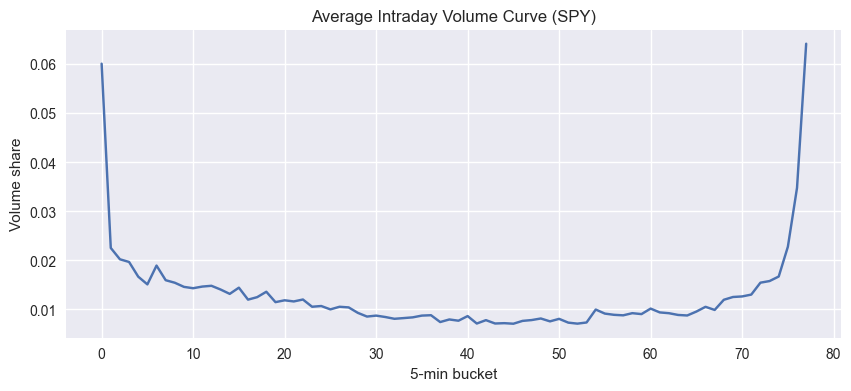

In [ ]:
# Intraday Volume Curve

vol_curve = spy.groupby("bucket")["volume"].mean()
vol_curve = vol_curve / vol_curve.sum()   # weights sum to 1

print("Sum of volume weights:", round(vol_curve.sum(), 6))

plt.figure(figsize=(10, 4))
plt.plot(vol_curve.index, vol_curve.values)
plt.title("Average Intraday Volume Curve (SPY)")
plt.xlabel("5-min bucket")
plt.ylabel("Volume share")
plt.show()

In [ ]:
# Train / Test Split

days = spy.index.normalize().unique()

train_days = days[:45]
test_days  = days[45:]

train = spy[spy.index.normalize().isin(train_days)].copy()
test  = spy[spy.index.normalize().isin(test_days)].copy()

print("Train days:", len(train_days))
print("Test days: ", len(test_days))

Train days: 45
Test days:  15


In [ ]:
# Sigma Calibration

intraday_train = train[train["bucket"] > 0]
sigma_hat      = intraday_train["ret"].std()

print("Intraday sigma (per-bar return vol):", round(sigma_hat, 8))
print("Approx daily vol (× √78):          ", round(sigma_hat * np.sqrt(78), 6))

Intraday sigma (per-bar return vol): 0.00068473
Approx daily vol (× √78):           0.006047


In [ ]:
# TWAP Execution


def make_twap_schedule(Q, n_bars):
    """
    Split Q shares as evenly as possible across n_bars.
    Distributes rounding to *last* bars (away from the front-loaded AC region)
    so the two strategies are easier to distinguish visually.
    """
    base      = Q // n_bars
    remainder = Q %  n_bars
    trades    = np.full(n_bars, base, dtype=int)
    if remainder > 0:
        trades[-remainder:] += 1
    return pd.Series(trades)


def simulate_twap(day_df, Q, fee_per_share=FEE, eta=ETA):
    n_bars   = len(day_df)
    schedule = make_twap_schedule(Q, n_bars).reset_index(drop=True)

    prices  = day_df["close"].reset_index(drop=True)
    spreads = day_df["half_spread"].reset_index(drop=True)
    volumes = day_df["volume"].reset_index(drop=True).clip(lower=1)

    impact     = prices * eta * (schedule / volumes)
    exec_price = prices + spreads + impact

    trading_cost = (schedule * exec_price).sum()
    fees         = schedule.sum() * fee_per_share
    return schedule, trading_cost + fees

In [ ]:
# VWAP Execution

def make_vwap_schedule(day_df, Q, vol_curve):
    buckets = day_df["bucket"].values
    weights = vol_curve.loc[buckets].values
    weights = weights / weights.sum()

    trades = np.floor(Q * weights).astype(int)
    diff   = Q - trades.sum()
    if diff > 0:
        trades[:diff] += 1
    return pd.Series(trades)


def simulate_vwap(day_df, Q, vol_curve, fee_per_share=FEE, eta=ETA):
    schedule = make_vwap_schedule(day_df, Q, vol_curve).reset_index(drop=True)

    prices  = day_df["close"].reset_index(drop=True)
    spreads = day_df["half_spread"].reset_index(drop=True)
    volumes = day_df["volume"].reset_index(drop=True).clip(lower=1)

    impact     = prices * eta * (schedule / volumes)
    exec_price = prices + spreads + impact

    trading_cost = (schedule * exec_price).sum()
    fees         = schedule.sum() * fee_per_share
    return schedule, trading_cost + fees

In [ ]:
#  Almgren–Chriss Schedule 

def calibrate_lambda(target_kT, n_bars, sigma_ret, price, eta=ETA):
    """
    Return λ such that k*T = target_kT.
    k   = sqrt(λ σ² / η)   where σ is in price units
    ⟹  λ = (target_kT/T)² * η / σ²
    """
    sigma_price = sigma_ret * price
    k_target    = target_kT / n_bars
    lam         = (k_target ** 2) * eta / (sigma_price ** 2)
    return lam


def make_ac_schedule(Q, n_bars, sigma_ret, price, lam, eta=ETA):
    """
    Parameters
    ----------
    sigma_ret : per-bar *return* volatility (from training data)
    price     : arrival price used to convert return vol → price vol
    lam       : risk-aversion parameter (calibrate with calibrate_lambda)
    """
    T           = n_bars
    sigma_price = sigma_ret * price        
    k           = np.sqrt((lam * sigma_price ** 2) / eta)

    t = np.arange(T + 1)

    x = Q * np.sinh(k * (T - t)) / np.sinh(k * T)

    trades = x[:-1] - x[1:]                 # shares sold each period
    trades = np.round(trades).astype(int)
    trades = np.clip(trades, 0, None)       

    # Rounding
    diff = Q - trades.sum()
    if diff > 0:
        trades[:diff] += 1
    elif diff < 0:
        for i in range(abs(diff)):
            idx = -(i + 1)
            trades[idx] = max(0, trades[idx] - 1)

    return pd.Series(trades)


def simulate_ac(day_df, Q, sigma_ret, lam, eta=ETA, fee_per_share=FEE):
    n             = len(day_df)
    arrival_price = day_df["close"].iloc[0]  # ← FIX: pass arrival price

    schedule = make_ac_schedule(
        Q, n_bars=n, sigma_ret=sigma_ret, price=arrival_price, lam=lam, eta=eta
    ).reset_index(drop=True)

    prices  = day_df["close"].reset_index(drop=True)
    spreads = day_df["half_spread"].reset_index(drop=True)
    volumes = day_df["volume"].reset_index(drop=True).clip(lower=1)

    impact     = prices * eta * (schedule / volumes)
    exec_price = prices + spreads + impact

    trading_cost = (schedule * exec_price).sum()
    fees         = schedule.sum() * fee_per_share
    return schedule, trading_cost + fees


# Calibrate λ on training data 
avg_price    = train["close"].mean()
n_bars_day   = 78  

lam_calibrated = calibrate_lambda(
    target_kT=1.5,
    n_bars=n_bars_day,
    sigma_ret=sigma_hat,
    price=avg_price
)

print(f"Average training price : {avg_price:.2f}")
print(f"sigma_hat (return)     : {sigma_hat:.8f}")
print(f"sigma_price            : {sigma_hat * avg_price:.4f}  $/bar")
print(f"Calibrated λ           : {lam_calibrated:.4e}")

k_check = np.sqrt((lam_calibrated * (sigma_hat * avg_price)**2) / ETA)
print(f"k*T (should be ≈ 1.5)  : {k_check * n_bars_day:.4f}")

Average training price : 687.62
sigma_hat (return)     : 0.00068473
sigma_price            : 0.4708  $/bar
Calibrated λ           : 1.6683e-04
k*T (should be ≈ 1.5)  : 1.5000


In [ ]:
test_days_list = list(test.groupby("date"))
day0, df0      = test_days_list[0]

ac_sched, ac_cost = simulate_ac(df0, Q, sigma_hat, lam=lam_calibrated)

print(f"Day         : {day0}")
print(f"Total shares: {ac_sched.sum():,}   (should == {Q:,})")
print(f"AC cost     : ${ac_cost:,.2f}")
print("\nFirst 10 bars:", ac_sched.values[:10])
print("Last  10 bars:", ac_sched.values[-10:])

Day         : 2026-02-19
Total shares: 50,000   (should == 50,000)
AC cost     : $34,203,110.87

First 10 bars: [1049 1031 1014  997  980  963  947  932  916  901]
Last  10 bars: [461 459 458 457 456 455 454 454 453 452]


In [ ]:
# Backtesting

results = []

for day, day_df in test_days_list:
    arrival    = day_df["close"].iloc[0]
    ideal_cost = Q * arrival

    twap_sched, twap_cost = simulate_twap(day_df, Q)
    vwap_sched, vwap_cost = simulate_vwap(day_df, Q, vol_curve)
    ac_sched,   ac_cost   = simulate_ac(day_df, Q, sigma_hat, lam=lam_calibrated)

    results.append({
        "date"          : day,
        "arrival_price" : arrival,
        "twap_cost"     : twap_cost,
        "vwap_cost"     : vwap_cost,
        "ac_cost"       : ac_cost,
        "twap_IS"       : (twap_cost - ideal_cost) / ideal_cost,
        "vwap_IS"       : (vwap_cost - ideal_cost) / ideal_cost,
        "ac_IS"         : (ac_cost   - ideal_cost) / ideal_cost,
    })

results = pd.DataFrame(results).set_index("date")
print(results[["twap_IS", "vwap_IS", "ac_IS"]].round(6))

             twap_IS   vwap_IS     ac_IS
date                                    
2026-02-19 -0.000095  0.000168  0.000164
2026-02-20  0.006278  0.005999  0.005900
2026-02-23 -0.009569 -0.008765 -0.008982
2026-02-24  0.008421  0.007750  0.007946
2026-02-25  0.001969  0.001825  0.001643
2026-02-26 -0.006139 -0.005297 -0.006015
2026-02-27  0.001128  0.001289  0.001126
2026-03-02  0.006819  0.006105  0.006253
2026-03-03  0.004492  0.003832  0.003207
2026-03-04  0.004095  0.003439  0.003578
2026-03-05 -0.006721 -0.005455 -0.005967
2026-03-06  0.002418  0.001798  0.002227
2026-03-09  0.005089  0.005517  0.003986
2026-03-10  0.003297  0.002222  0.003051
2026-03-11  0.000545  0.000449  0.000543


In [ ]:
# Summary

is_cols = ["twap_IS", "vwap_IS", "ac_IS"]

summary = pd.DataFrame({
    "Mean IS (bps)" : results[is_cols].mean() * 1e4,
    "Std IS (bps)"  : results[is_cols].std()  * 1e4,
    "Min IS (bps)"  : results[is_cols].min()  * 1e4,
    "Max IS (bps)"  : results[is_cols].max()  * 1e4,
    "Sharpe (IS)"   : results[is_cols].mean() / results[is_cols].std(),
}).T

summary.columns = ["TWAP", "VWAP", "AC"]
print(summary.round(4))

# Win-rate: fraction of days AC beats TWAP
ac_beats_twap = (results["ac_IS"] < results["twap_IS"]).mean()
ac_beats_vwap = (results["ac_IS"] < results["vwap_IS"]).mean()
print(f"\nAC beats TWAP on {ac_beats_twap:.0%} of test days")
print(f"AC beats VWAP on {ac_beats_vwap:.0%} of test days")

                  TWAP     VWAP       AC
Mean IS (bps)  14.6847  13.9167  12.4401
Std IS (bps)   52.3662  46.9981  48.0934
Min IS (bps)  -95.6892 -87.6496 -89.8162
Max IS (bps)   84.2080  77.4964  79.4608
Sharpe (IS)     0.2804   0.2961   0.2587

AC beats TWAP on 73% of test days
AC beats VWAP on 60% of test days


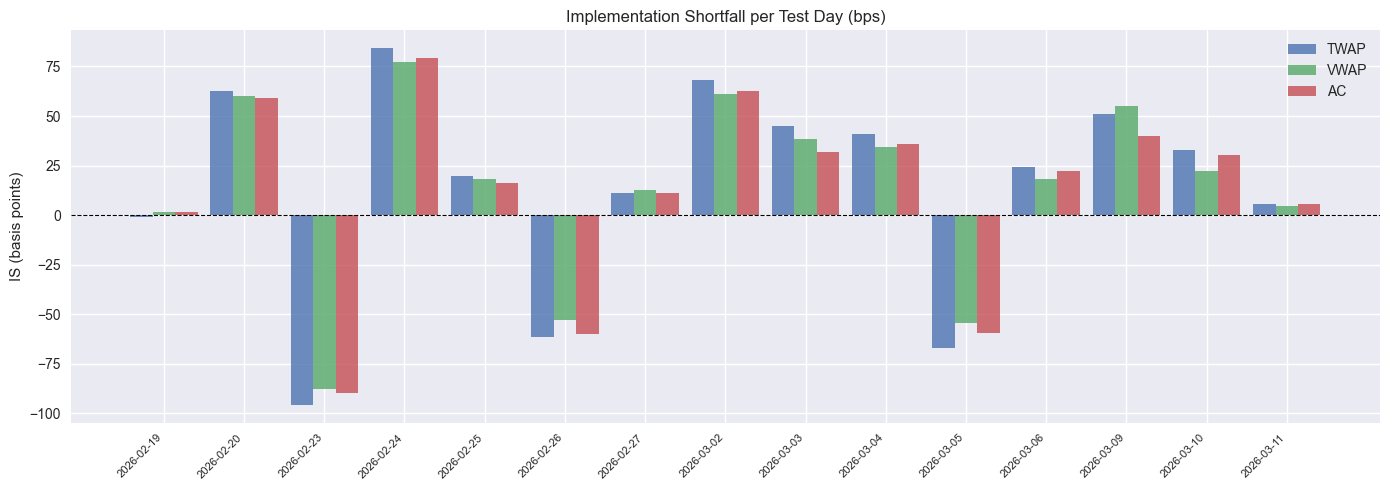

In [ ]:
# IS per Day - Bar Chart

x     = np.arange(len(results))
width = 0.28

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - width, results["twap_IS"] * 1e4, width, label="TWAP", alpha=0.8)
ax.bar(x,         results["vwap_IS"] * 1e4, width, label="VWAP", alpha=0.8)
ax.bar(x + width, results["ac_IS"]   * 1e4, width, label="AC",   alpha=0.8)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(
    [str(d) for d in results.index],
    rotation=45, ha="right", fontsize=8
)
ax.set_title("Implementation Shortfall per Test Day (bps)")
ax.set_ylabel("IS (basis points)")
ax.legend()
plt.tight_layout()
plt.show()

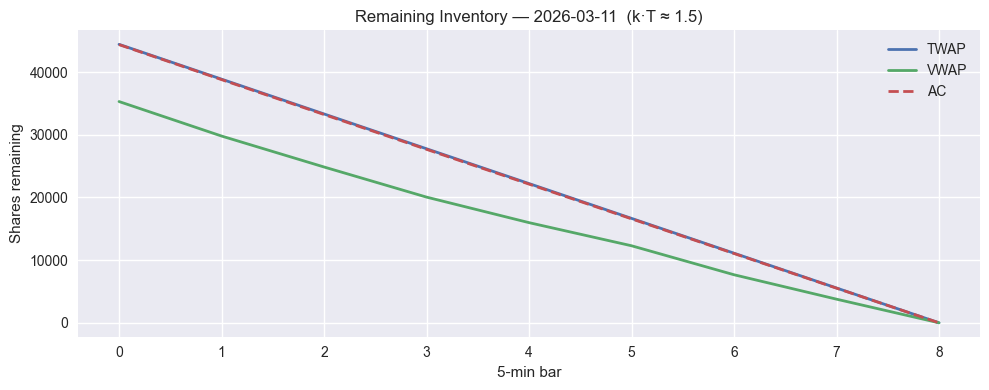

Shares remaining at bar 4 (midday):
  TWAP :   22,224  (44.4% of Q)
  VWAP :   15,986  (32.0% of Q)
  AC   :   22,135  (44.3% of Q)


In [ ]:
# Inventory Trajectory


last_day, last_df = test_days_list[-1]

twap_s, _ = simulate_twap(last_df, Q)
vwap_s, _ = simulate_vwap(last_df, Q, vol_curve)
ac_s,   _ = simulate_ac(last_df, Q, sigma_hat, lam=lam_calibrated)

inv_twap = Q - twap_s.cumsum().values
inv_vwap = Q - vwap_s.cumsum().values
inv_ac   = Q - ac_s.cumsum().values

plt.figure(figsize=(10, 4))
plt.plot(inv_twap, label="TWAP",  linewidth=2)
plt.plot(inv_vwap, label="VWAP",  linewidth=2)
plt.plot(inv_ac,   label="AC",    linewidth=2, linestyle="--")
plt.title(f"Remaining Inventory — {last_day}  (k·T ≈ 1.5)")
plt.xlabel("5-min bar")
plt.ylabel("Shares remaining")
plt.legend()
plt.tight_layout()
plt.show()

halfway = len(inv_ac) // 2
print(f"Shares remaining at bar {halfway} (midday):")
print(f"  TWAP : {inv_twap[halfway]:>8,}  ({inv_twap[halfway]/Q:.1%} of Q)")
print(f"  VWAP : {inv_vwap[halfway]:>8,}  ({inv_vwap[halfway]/Q:.1%} of Q)")
print(f"  AC   : {inv_ac[halfway]:>8,}  ({inv_ac[halfway]/Q:.1%} of Q)")

    kT  mean_IS_bps  std_IS_bps
0  0.5      14.3863     50.0434
1  1.0      13.5755     48.5521
2  1.5      12.4401     46.4626
3  2.0      11.1811     44.1351
4  3.0       8.7910     39.6763
5  5.0       5.3808     33.0112


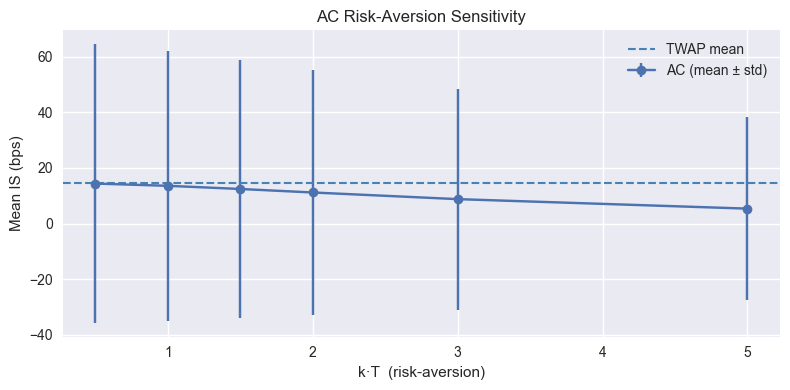

In [ ]:
#  Sensitivity : k·T vs Mean IS


kT_targets = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
kT_results = []

for kT in kT_targets:
    lam_kT = calibrate_lambda(kT, n_bars_day, sigma_hat, avg_price)
    day_IS = []
    for day, day_df in test_days_list:
        arr  = day_df["close"].iloc[0]
        _, c = simulate_ac(day_df, Q, sigma_hat, lam=lam_kT)
        day_IS.append((c - Q * arr) / (Q * arr))
    kT_results.append({"kT": kT, "mean_IS_bps": np.mean(day_IS) * 1e4,
                        "std_IS_bps":  np.std(day_IS)  * 1e4})

kT_df = pd.DataFrame(kT_results)
print(kT_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    kT_df["kT"], kT_df["mean_IS_bps"],
    yerr=kT_df["std_IS_bps"],
    marker="o", capsize=4, label="AC (mean ± std)"
)

twap_mean = results["twap_IS"].mean() * 1e4
ax.axhline(twap_mean, color="steelblue", linestyle="--", linewidth=1.5, label="TWAP mean")

ax.set_xlabel("k·T  (risk-aversion)")
ax.set_ylabel("Mean IS (bps)")
ax.set_title("AC Risk-Aversion Sensitivity")
ax.legend()
plt.tight_layout()
plt.show()